### FEATURES
The various features of the dataset are explained below:

1. **Airline** — Name of the airline company. Categorical feature with 12 unique airlines.
2. **Date_of_Journey** — Date of the flight journey (DD/MM/YYYY). Split into Date, Month, Year during feature engineering.
3. **Source** — City from which the flight takes off. Categorical feature with 5 unique cities: Bangalore, Kolkata, Delhi, Chennai, Mumbai.
4. **Destination** — City where the flight will land. Categorical feature with 6 unique cities: New Delhi, Bangalore, Cochin, Kolkata, Delhi, Hyderabad.
5. **Route** — Flight route including stops. Dropped during feature engineering (redundant with Total_Stops).
6. **Dep_Time** — Departure time (HH:MM). Split into Dep_Hour and Dep_Minute during feature engineering.
7. **Arrival_Time** — Arrival time (HH:MM). Split into Arrival_Hour and Arrival_Minute during feature engineering.
8. **Duration** — Total flight duration (e.g., 2h 50m). Split into Hour and Minute during feature engineering.
9. **Total_Stops** — Number of stops between source and destination. Ordinal feature mapped to numerical: non-stop=0, 1 stop=1, 2 stops=2, 3 stops=3, 4 stops=4.
10. **Additional_Info** — Extra information about the flight (meal included, no info, etc.). Encoded using pd.get_dummies().
11. **Price** — **Target variable**. Ticket price in INR.

In [ ]:
#importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline   #used to show charts/plots inside the notebook itself, right below the code cell.

In [4]:
df=pd.read_excel('flight_price.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [5]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [6]:
#get the basic info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
#with help of feature engineering process we will separate date, month and year from the given date.
##Feature Engineering
df['Date']=df['Date_of_Journey'].str.split('/').str[0]
df['Month']=df['Date_of_Journey'].str.split('/').str[1]
df['Year']=df['Date_of_Journey'].str.split('/').str[2]

In [9]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,05,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,06,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,05,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,01,03,2019


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
 11  Date             10683 non-null  object
 12  Month            10683 non-null  object
 13  Year             10683 non-null  object
dtypes: int64(1), object(13)
memory usage: 1.1+ MB


In [11]:
#our 3 newly created features Date, Month and Year are still object datatypes. we need to convert them into numerical datatypes.
df['Date']=df['Date'].astype(int)
df['Month']=df['Month'].astype(int)
df['Year']=df['Year'].astype(int)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
 11  Date             10683 non-null  int64 
 12  Month            10683 non-null  int64 
 13  Year             10683 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 1.1+ MB


In [13]:
#Now we have converted new features into integer datatype and as we do not need the original date_of_journey column we will drop it.
#drop Date_of_Journey
df.drop('Date_of_Journey',axis=1,inplace=True)

axis = 1 -->removes column
axis = 0 --> removes row

In Pandas, axis tells you what you want to remove or operate on.

df.drop('col1', axis=1)   --> removes column
df.drop(0, axis=0)        --> removes row index 0

Inplace= True --> this controls whether changes happen in same dataframe or not.
inplace=True	            Modify original df directly
inplace=False (default)	    Return a new DataFrame (original unchanged)

In [14]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [19]:
df['Arrival_Time']=df['Arrival_Time'].apply(lambda x:x.split(' ')[0]) #we are using lambda fun to split 01:10 22 Mar which will give us only time 01:10

In [20]:
#lets create separate columns for Arrival_Time as Hours and Minutes
df['Arrival_Hour']=df['Arrival_Time'].str.split(':').str[0]
df['Arrival_Minute']=df['Arrival_Time'].str.split(':').str[1]

In [21]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,24,3,2019,01,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,9,6,2019,04,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,21,35


In [22]:
df['Arrival_Hour']=df['Arrival_Hour'].astype(int)
df['Arrival_Minute']=df['Arrival_Minute'].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Route            10682 non-null  object
 4   Dep_Time         10683 non-null  object
 5   Arrival_Time     10683 non-null  object
 6   Duration         10683 non-null  object
 7   Total_Stops      10682 non-null  object
 8   Additional_Info  10683 non-null  object
 9   Price            10683 non-null  int64 
 10  Date             10683 non-null  int64 
 11  Month            10683 non-null  int64 
 12  Year             10683 non-null  int64 
 13  Arrival_Hour     10683 non-null  int64 
 14  Arrival_Minute   10683 non-null  int64 
dtypes: int64(6), object(9)
memory usage: 1.2+ MB


In [24]:
df.drop('Arrival_Time', axis=1,inplace=True)

In [25]:
df.head(2)

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897,24,3,2019,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662,1,5,2019,13,15


In [26]:
df['Dep_Hour']=df['Dep_Time'].str.split(':').str[0]
df['Dep_Minute']=df['Dep_Time'].str.split(':').str[1]

In [27]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,7h 25m,2 stops,No info,7662,1,5,2019,13,15,05,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,19h,2 stops,No info,13882,9,6,2019,4,25,09,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,5h 25m,1 stop,No info,6218,12,5,2019,23,30,18,05
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,4h 45m,1 stop,No info,13302,1,3,2019,21,35,16,50


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Route            10682 non-null  object
 4   Dep_Time         10683 non-null  object
 5   Duration         10683 non-null  object
 6   Total_Stops      10682 non-null  object
 7   Additional_Info  10683 non-null  object
 8   Price            10683 non-null  int64 
 9   Date             10683 non-null  int64 
 10  Month            10683 non-null  int64 
 11  Year             10683 non-null  int64 
 12  Arrival_Hour     10683 non-null  int64 
 13  Arrival_Minute   10683 non-null  int64 
 14  Dep_Hour         10683 non-null  object
 15  Dep_Minute       10683 non-null  object
dtypes: int64(6), object(10)
memory usage: 1.3+ MB


In [29]:
df['Dep_Hour']=df['Dep_Hour'].astype(int)
df['Dep_Minute']=df['Dep_Minute'].astype(int)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Route            10682 non-null  object
 4   Dep_Time         10683 non-null  object
 5   Duration         10683 non-null  object
 6   Total_Stops      10682 non-null  object
 7   Additional_Info  10683 non-null  object
 8   Price            10683 non-null  int64 
 9   Date             10683 non-null  int64 
 10  Month            10683 non-null  int64 
 11  Year             10683 non-null  int64 
 12  Arrival_Hour     10683 non-null  int64 
 13  Arrival_Minute   10683 non-null  int64 
 14  Dep_Hour         10683 non-null  int64 
 15  Dep_Minute       10683 non-null  int64 
dtypes: int64(8), object(8)
memory usage: 1.3+ MB


In [31]:
df.drop('Dep_Time', axis=1, inplace=True)

In [32]:
df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50


In [35]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', nan, '4 stops'],
      dtype=object)

In [ ]:
#to find null records from Total_Stops
df[df['Total_Stops'].isnull()]  #This is called boolean indexing (filtering) in pandas.Inner part creates true/false series.
#gives us rows of df where condition is TRUE.

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
9039,Air India,Delhi,Cochin,NaN,23h 40m,NaN,No info,7480,6,5,2019,9,25,9,45


In [38]:
#conveting categorical feature value sinto numerical values in Total_Stops by mapping ordinal labels to unique values.
df['Total_Stops']=df['Total_Stops'].map({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4,np.nan:1})

In [39]:
df[df['Total_Stops'].isnull()]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute


In [40]:
df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,5,2019,13,15,5,50


In [41]:
df.drop('Route',axis=1,inplace=True)

In [42]:
df.head(2)

,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662,1,5,2019,13,15,5,50


In [77]:
df['Hour'] = df['Duration'].str.extract(r'(\d+)h').fillna(0).astype(int)
df['Minute'] = df['Duration'].str.extract(r'(\d+)m').fillna(0).astype(int)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Duration         10683 non-null  object
 4   Total_Stops      10683 non-null  int64 
 5   Additional_Info  10683 non-null  object
 6   Price            10683 non-null  int64 
 7   Date             10683 non-null  int64 
 8   Month            10683 non-null  int64 
 9   Year             10683 non-null  int64 
 10  Arrival_Hour     10683 non-null  int64 
 11  Arrival_Minute   10683 non-null  int64 
 12  Dep_Hour         10683 non-null  int64 
 13  Dep_Minute       10683 non-null  int64 
 14  Hour             10683 non-null  int64 
 15  Minute           10683 non-null  int64 
dtypes: int64(11), object(5)
memory usage: 1.3+ MB


In [ ]:
df['Minute'].unique()


array([50, 25,  0, 45, 30,  5, 15, 35, 10, 20, 55, 40])

In [83]:
df['Hour'].unique()

array([ 2,  7, 19,  5,  4, 15, 21, 25, 13, 12, 26, 22, 23, 20, 10,  6, 11,
        8, 16,  3, 27,  1, 14,  9, 18, 17, 24, 30, 28, 29, 37, 34, 38, 35,
       36, 47, 33, 32, 31, 42, 39,  0, 41, 40])

In [84]:
df.drop('Duration',axis=1,inplace=True)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Source           10683 non-null  object
 2   Destination      10683 non-null  object
 3   Total_Stops      10683 non-null  int64 
 4   Additional_Info  10683 non-null  object
 5   Price            10683 non-null  int64 
 6   Date             10683 non-null  int64 
 7   Month            10683 non-null  int64 
 8   Year             10683 non-null  int64 
 9   Arrival_Hour     10683 non-null  int64 
 10  Arrival_Minute   10683 non-null  int64 
 11  Dep_Hour         10683 non-null  int64 
 12  Dep_Minute       10683 non-null  int64 
 13  Hour             10683 non-null  int64 
 14  Minute           10683 non-null  int64 
dtypes: int64(11), object(4)
memory usage: 1.2+ MB


In [86]:
df.head(2)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,Hour,Minute
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,1,10,22,20,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,13,15,5,50,7,25


In [87]:
df['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [88]:
df['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [89]:
df['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [90]:
df['Additional_Info'].unique()

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [91]:
#converting all above categorical features into numerical using 'ONEHOTENCODER'
#One-Hot Encoding converts categorical data (text) into numbers (0 & 1) so models can understand it.
from sklearn.preprocessing import OneHotEncoder

In [92]:
encoder=OneHotEncoder()

In [ ]:
#save encoded data
encoded_array = encoder.fit_transform(df[['Airline','Source','Destination']]).toarray()

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out()
)

In [97]:
#merge with original dataframe
df = pd.concat([df, encoded_df], axis=1)

In [98]:
#drop old columns
df.drop(['Airline','Source','Destination'], axis=1, inplace=True)

In [99]:
df.head()

,Total_Stops,Additional_Info,Price,Date,Month,Year,Arrival_Hour,Arrival_Minute,Dep_Hour,Dep_Minute,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,No info,3897,24,3,2019,1,10,22,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,No info,7662,1,5,2019,13,15,5,50,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,No info,13882,9,6,2019,4,25,9,25,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,No info,6218,12,5,2019,23,30,18,5,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1,No info,13302,1,3,2019,21,35,16,50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Total_Stops                                10683 non-null  int64  
 1   Additional_Info                            10683 non-null  object 
 2   Price                                      10683 non-null  int64  
 3   Date                                       10683 non-null  int64  
 4   Month                                      10683 non-null  int64  
 5   Year                                       10683 non-null  int64  
 6   Arrival_Hour                               10683 non-null  int64  
 7   Arrival_Minute                             10683 non-null  int64  
 8   Dep_Hour                                   10683 non-null  int64  
 9   Dep_Minute                                 10683 non-null  int64  
 10  Hour                  

In [101]:
additional_encoded = pd.get_dummies(df['Additional_Info'], prefix='Additional_Info')

df = pd.concat([df, additional_encoded], axis=1)

df.drop('Additional_Info', axis=1, inplace=True)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 44 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Total_Stops                                   10683 non-null  int64  
 1   Price                                         10683 non-null  int64  
 2   Date                                          10683 non-null  int64  
 3   Month                                         10683 non-null  int64  
 4   Year                                          10683 non-null  int64  
 5   Arrival_Hour                                  10683 non-null  int64  
 6   Arrival_Minute                                10683 non-null  int64  
 7   Dep_Hour                                      10683 non-null  int64  
 8   Dep_Minute                                    10683 non-null  int64  
 9   Hour                                          10683 non-null 

1. Which airline is most expensive?

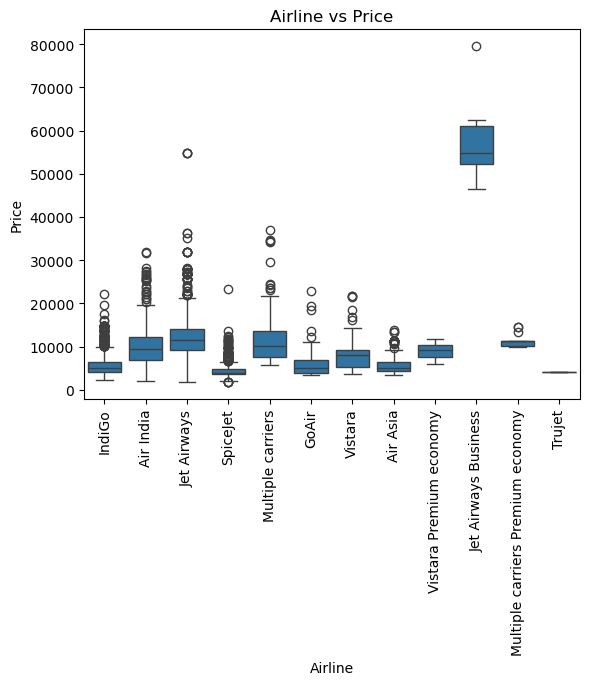

In [106]:
airline_cols = [col for col in df.columns if 'Airline_' in col]

df['Airline'] = df[airline_cols].idxmax(axis=1)
df['Airline'] = df['Airline'].str.replace('Airline_', '')

sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=90)
plt.title("Airline vs Price")
plt.show()

Airline VS Price Insights:
Jet Airways Business is the most expensive airline, having the highest ticket prices among all airlines.
Jet Airways also has higher average prices compared to most other airlines.
Budget airlines like IndiGo and SpiceJet generally have lower prices.

2. Which route is most expensive?

In [104]:
source_cols = [col for col in df.columns if 'Source_' in col]
dest_cols = [col for col in df.columns if 'Destination_' in col]

df['Source'] = df[source_cols].idxmax(axis=1)
df['Destination'] = df[dest_cols].idxmax(axis=1)

df.groupby(['Source','Destination'])['Price'].mean().sort_values(ascending=False)

Source           Destination          
Source_Banglore  Destination_New Delhi    11917.716738
Source_Delhi     Destination_Cochin       10539.439057
Source_Kolkata   Destination_Banglore      9158.389411
Source_Banglore  Destination_Delhi         5143.918577
Source_Mumbai    Destination_Hyderabad     5059.708752
Source_Chennai   Destination_Kolkata       4789.892388
Name: Price, dtype: float64

Route Vs Price Insights:
The route Banglore → New Delhi is the most expensive, with the highest average price.
Other expensive routes include Delhi → Cochin and Kolkata → Banglore.
Routes like Chennai → Kolkata are comparatively cheaper.

3. Does number of stops affect price?

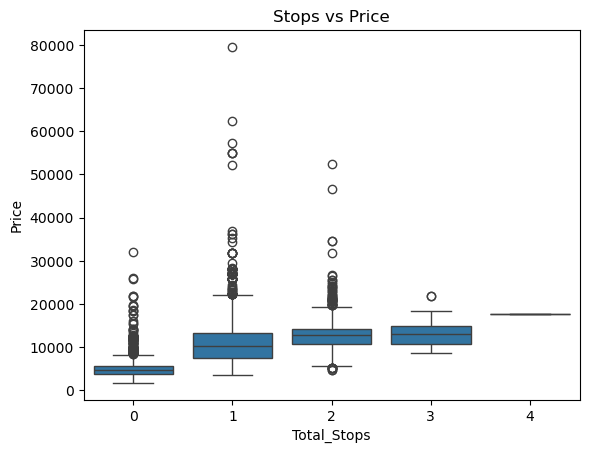

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Total_Stops', y='Price', data=df)
plt.title("Stops vs Price")
plt.show()

Stops VS Price Insights:
Flight price increases as the number of stops increases.
Non-stop flights have the lowest average price (~5024), while flights with 4 stops have the highest (~17686).
Flights with 1 stop already show a significant increase in price compared to non-stop flights.
This shows that more stops are generally associated with higher prices in this dataset.


Final Summary:
Flights with more stops tend to have higher prices.
Non-stop flights are the cheapest on average, while flights with multiple stops have significantly higher prices.
This indicates that number of stops is an important factor affecting ticket price.

In [109]:
df.groupby('Total_Stops')['Price'].mean()

Total_Stops
0     5024.900315
1    10593.570032
2    12715.807895
3    13112.000000
4    17686.000000
Name: Price, dtype: float64